# Introduction
| ![Profile](profile.png) | <div style="text-align: justify;">Hello!<br><br>I am Ryo Nurizki, a recent Civil Engineering graduate from Institut Teknologi Sepuluh Nopember, currently shifting to Data Science and AI/ML Engineering. Working on my thesis, I was challenged with collecting and processing unstructured data, and producing models to support public-first projects. Civil Engineering taught me that data is a gateway to solve large-scale problems, encouraging me to seek a role that focuses on leveraging data to solve public and business problems.<br><br>Through Dibimbing.id, I thrived in a 6-month bootcamp learning Data Science. Currently, I have built 5+ production-ready projects across Machine Learning, Deep Learning, MLOps, Computer Vision, Recommender Systems, and RAG.</div> |
|---|---|

---

## Professional Experience

**Project Development Intern** — PT. MRT Jakarta
*Jun 2025 — Aug 2025*
- Optimized inter-institutional coordination by building a coherent framework from 4+ Ministerial Regulations, reducing bureaucratic obstacles that previously stalled project implementation.

**Reliability & Project Development Intern** — PT. Pertamina Patra Niaga
*Jan 2025 — Feb 2025*
- Streamlined inventory tracking from manual logbook processes by designing a BI platform managing utilization cycles of 70+ assets across multiple categories.

**Pro-Bono Consulting Analyst** — 180 Degrees Consulting ITS
*Feb 2024 — Feb 2025*
- Delivered a go-to-market strategy for a footwear brand via market, customer journey, and financial projection analyses, culminating in a recommendation deck projected to reach 590K+ users and 500+ offline prospects.

---

## Leadership Experience

**Head of Visual Media** — Himpunan Mahasiswa Sipil ITS
*Jan 2025 — Dec 2025*

**Director of Creative** — ITS Model United Nations 2024
*Jan 2024 — Dec 2024*

**Vice Director of Creative** — Jakarta International Model United Nations 2024
*Sep 2023 — Aug 2024*

---

## Education

**Data Science and ML Bootcamp** — Dibimbing.id
*Jan 2026 — Jul 2026* &nbsp;|&nbsp; Grade: 99.4

**B. Eng. in Civil Engineering** — ITS Surabaya
*Aug 2022 — Feb 2026* &nbsp;|&nbsp; GPA: 3.65/4.00

---

## Socials

📧 [sr.nurizki@gmail.com](mailto:sr.nurizki@gmail.com) &nbsp;·&nbsp; 🐙 [github.com/srnurizki](https://github.com/srnurizki) &nbsp;·&nbsp; 💼 [linkedin.com/in/rynurizki](https://linkedin.com/in/rynurizki) &nbsp;·&nbsp; ✍️ [medium.com/rynzki](https://medium.com/rynzki)

# SEPHORA Wellness Shopping Agent

<img src="sephora_banner.jpg" width="100%" style="max-width:1500px; border-radius:15px;">

> **An AI-driven assistant that guides you through hundreds of SEPHORA products, matched to the skin and hair you deserve.**

---

## Introduction

### The Gap in Online Beauty Shopping

Marketplaces today list products alongside their suitability for certain skin types, target concerns, and customer reviews, but these details exist only as **filters**. They tell you *what's available*, not *what's right for you*.

When someone is dealing with a specific skin, body, or hair concern, what they actually need is closer to a consultation: what's causing this, what ingredient should I look for, and what do real people say about the products that contain it. Today, that kind of guidance is only available offline, through in-store sales consultants, or by manually digging through social media and the wider internet, comparing scattered opinions one post at a time.

<img src="skincare_shopping.jpg" width="100%" style="max-width:1500px; border-radius:15px;">

### Bridging the Gap

This project closes that gap by placing an **agent between the user and the product catalog**.

Instead of browsing filters, the user simply describes what they're experiencing, dryness, irritation, breakouts, oiliness, or any other skin, body, or hair concern. The agent takes it from there:

1. **Identifies** the underlying skin/hair concern from the user's own words
2. **Matches** it to the ingredient(s) known to address that concern
3. **Searches** the product catalog for items containing those ingredients
4. **Verifies** the result against real-world signal, surfacing products backed by positive ratings and reviews, not just ingredient match alone

The result: a recommendation that's grounded in both **formulation science** and **lived consumer experience**, delivered in a single conversation.

---

### How It Works

| Stage | Role |
|-------|------|
| **Agent 1 — Ingredient Mapper** | Maps your concern to functional ingredients |
| **Agent 2 — Product Retriever** | Finds SEPHORA products containing those ingredients |
| **Ranking** | Surfaces products with the highest ratings and review counts |
| **Review Summarizer** | Condenses what real users say about each pick |

### Datasets

| Source | Dataset |
|--------|---------|
| Kaggle | `nadyinky/sephora-products-and-skincare-reviews` |
| Kaggle | `rama87/indonesian-skincare-sample-dataset` |

---

# Preprocessing

## Import Libraries

In [1]:
# <<<./ Import Libraries
import sys; sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import preprocess.IngredientsPreprocess as ppi
import preprocess.SephoraPreprocess as pps
from wordcloud import WordCloud

## Preprocess Data

### Sephora Products

In [2]:
# <<<./ Load Sephora Products Dataset
seph_prod_df = pd.read_csv('../data/raw/sephora/product.csv')
seph_prod_df.head(5)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [3]:
# <<<./ Diagnostic: Sephora Products
print('# ——————— /DATA DIAGNOSTIC/ ——————————')
print(f'\n[1] Rows           : {seph_prod_df.shape[0]}  \n[2] Columns        : {seph_prod_df.shape[1]}')
seph_prod_nan = {
    col: seph_prod_df[col].isna().sum()/seph_prod_df.shape[0] * 100 for col in seph_prod_df.columns}
spnan_df = pd.Series(seph_prod_nan).to_frame(name='null_pct')
print(f'[3] Missing Values :\n{spnan_df}')
print(f'[4] Duplicates     : {seph_prod_df.duplicated().sum() / seph_prod_df.shape[0] * 100 if seph_prod_df.duplicated().sum() > 0 else 0}%')

# ——————— /DATA DIAGNOSTIC/ ——————————

[1] Rows           : 8494  
[2] Columns        : 27
[3] Missing Values :
                     null_pct
product_id           0.000000
product_name         0.000000
brand_id             0.000000
brand_name           0.000000
loves_count          0.000000
rating               3.272899
reviews              3.272899
size                19.201789
variation_type      17.000235
variation_value     18.813280
variation_desc      85.283730
ingredients         11.125500
price_usd            0.000000
value_price_usd     94.690370
sale_price_usd      96.821286
limited_edition      0.000000
new                  0.000000
online_only          0.000000
out_of_stock         0.000000
sephora_exclusive    0.000000
highlights          25.983047
primary_category     0.000000
secondary_category   0.094184
tertiary_category   11.655286
child_count          0.000000
child_max_price     67.577113
child_min_price     67.577113
[4] Duplicates     : 0%


**Takeaways**
* Spotted missing values in several features:
  > rating, reviews, size, variation_type, variation_value, variation_desc, ingredients, value_price_usd, sale_price_usd, highlights, secondary_category, tertiary_category, child_max_price, and child_min_price.
* However, out of these features, several categories are excluded from knowledge base building"
    * value_price_usd and sale_price_usd: We only consider the base price listed on the catalogue.
    * variation_desc: Insignificant for the agent's context.
    * child_max_price, and child_min_price: Product's variation is not considered, only the main product is highlighted. Consequently, child_count will also be excluded.

**Missing Values Handling**
* rating and reviews will be imputed with zero (0). Imputing both of these with mean, kNN, or other manner of imputation would lead to false claim that is detrimental in the context of derma products that could lead to unwanted skin problems.
* Other features of string datatypes that are not excluded will be imputed with 'No description'-alike values, such as:
    * size: No sizes listed
    * variation_type: No variation types listed
    * variation_value: No variation values listed
    * ingredients: No ingredients listed
    * highlights: No highlights described
    * secondary_category: No secondary category
    * tertiary_category: No tertiary category
* As for numeric datatypes, their missing values follows with zero (0).

### Sephora Reviews

In [4]:
## Merge Reviews
files = glob.glob('data/sephora/reviews_*.csv')
dfs = [pd.read_csv(f) for f in files]
combined = pd.concat(dfs, ignore_index=True)
combined.to_csv('data/sephora/reviews.csv', index=False)

ValueError: No objects to concatenate

In [ ]:
# <<<./ Load Sephora Reviews Dataset
seph_revw_df = pd.read_csv('../data/raw/sephora/reviews.csv')
seph_revw_df.head(5)

In [ ]:
# <<<./ Diagnostic: Sephora Reviews 1
print('# ——————— /DATA DIAGNOSTIC/ ——————————')
print(f'\n[1] Rows           : {seph_revw_df.shape[0]}  \n[2] Columns        : {seph_revw_df.shape[1]}')
seph_revw_nan = {
    col: seph_revw_df[col].isna().sum()/seph_revw_df.shape[0] * 100 for col in seph_revw_df.columns}
srnan_df = pd.Series(seph_revw_nan).to_frame(name='null_pct')
print(f'[3] Missing Values :\n{srnan_df}')
print(f'[4] Duplicates     : {seph_revw_df.duplicated().sum() / seph_revw_df.shape[0] * 100 if seph_revw_df.duplicated().sum() > 0 else 0}%')

In [ ]:
# <<<./ Is 'is_recommended' truly NAN?
seph_revw_df['is_recommended'].value_counts()

In [ ]:
# <<<./ Check Ratio
len(seph_revw_df[seph_revw_df['is_recommended'] == 0.0]) / len(seph_revw_df[seph_revw_df['is_recommended'] == 1.0])

**Takeaways**
* Spotted missing values in several features:
  > is_recommended, helpfulness, review_text, review_title, skin_tone, eye_color, skin_type, hair_color
* However, is_recommended and helpfulness missing values are caused by their values being zero (0), that is equivalent of not being marked as recommended and no valid calculation for helpfulness (total_pos_feedback_count/total_feedback_count) respectively.
* Out of these features, few categories are excluded from knowledge base building
    * total_feedback_count, total_neg_feedback_count, total_pos_feedback_count: Their values have been represented by helpfulness value.
    * submission_time: Irrelevant for agent's context.

**Missing Values Handling**
* is_recommended and helpfulness will be imputed with zero (0), representing no recommendation or helpfulness as per the data's date.
* Reviews and features associated with physical features are imputed with 'No description'-alike values, such as:
    * review_text  : No reviews written
    * review_title : No reviews written
    * skin_tone    : No skin tone described
    * eye_color    : No eye color described
    * skin_type    : No skin type described
    * hair_color   : No hair color described

### Ingredients Description

In [ ]:
# <<<./ Load Ingredients Dataset
ingredients_df = pd.read_excel('data/ingredients/ingredients.xlsx')
ingredients_df.sample(5)

In [ ]:
# <<<./ Diagnostic: Ingredients
print('# ——————— /DATA DIAGNOSTIC/ ——————————')
print(f'\n[1] Rows           : {ingredients_df.shape[0]}  \n[2] Columns        : {ingredients_df.shape[1]}')
ingredients_nan = {
    col: ingredients_df[col].isna().sum()/ingredients_df.shape[0] * 100 for col in ingredients_df.columns}
ingr_df = pd.Series(ingredients_nan).to_frame(name='null_pct')
print(f'[3] Missing Values :\n{ingr_df}')
print(f'[4] Duplicates     : {ingredients_df.duplicated().sum() / ingredients_df.shape[0] * 100 if ingredients_df.duplicated().sum() > 0 else 0}%')

**Takeaways**
* Spotted missing values in few features:
  > function2, warning1, warning2
* These features' missing values are likely caused by having no relevant information associated to the feature, such as *Acetyl Heptapeptide-4* having no alternative function and no notable side-effects/warning.
* Out of these features, one feature is excluded: ingredient_charge. This feature is mostly informative to chemist/pharmacologist, therefore it's not relevant for agent whose purpose is to respond to general customers.

**Missing Values Handling**
* function2, warning1, warning2 will be imputed with 'No other function' and 'No known warning' respectively.

### Clean

In [ ]:
# <<<./ Clean Sephora Products and Reviews
seph_prod_df, seph_revw_df = pps.drop(seph_prod_df, seph_revw_df)
seph_prod_df, seph_revw_df = pps.impute(seph_prod_df, seph_revw_df)

# <<<./ Clean Ingredients
ingredients_df = ppi.drop(ingredients_df)
ingredients_df = ppi.impute(ingredients_df)

In [8]:
seph_prod_df, seph_revw_df = pd.read_csv('../data/cleaned/sephora/products-cleaned.csv'), pd.read_csv('../data/cleaned/sephora/reviews-cleaned.csv')

In [7]:
ingredients_df = pd.read_csv('../data/cleaned/ingredients/ingredients-cleaned.csv')

# Data Exploration

## SEPHORA Products

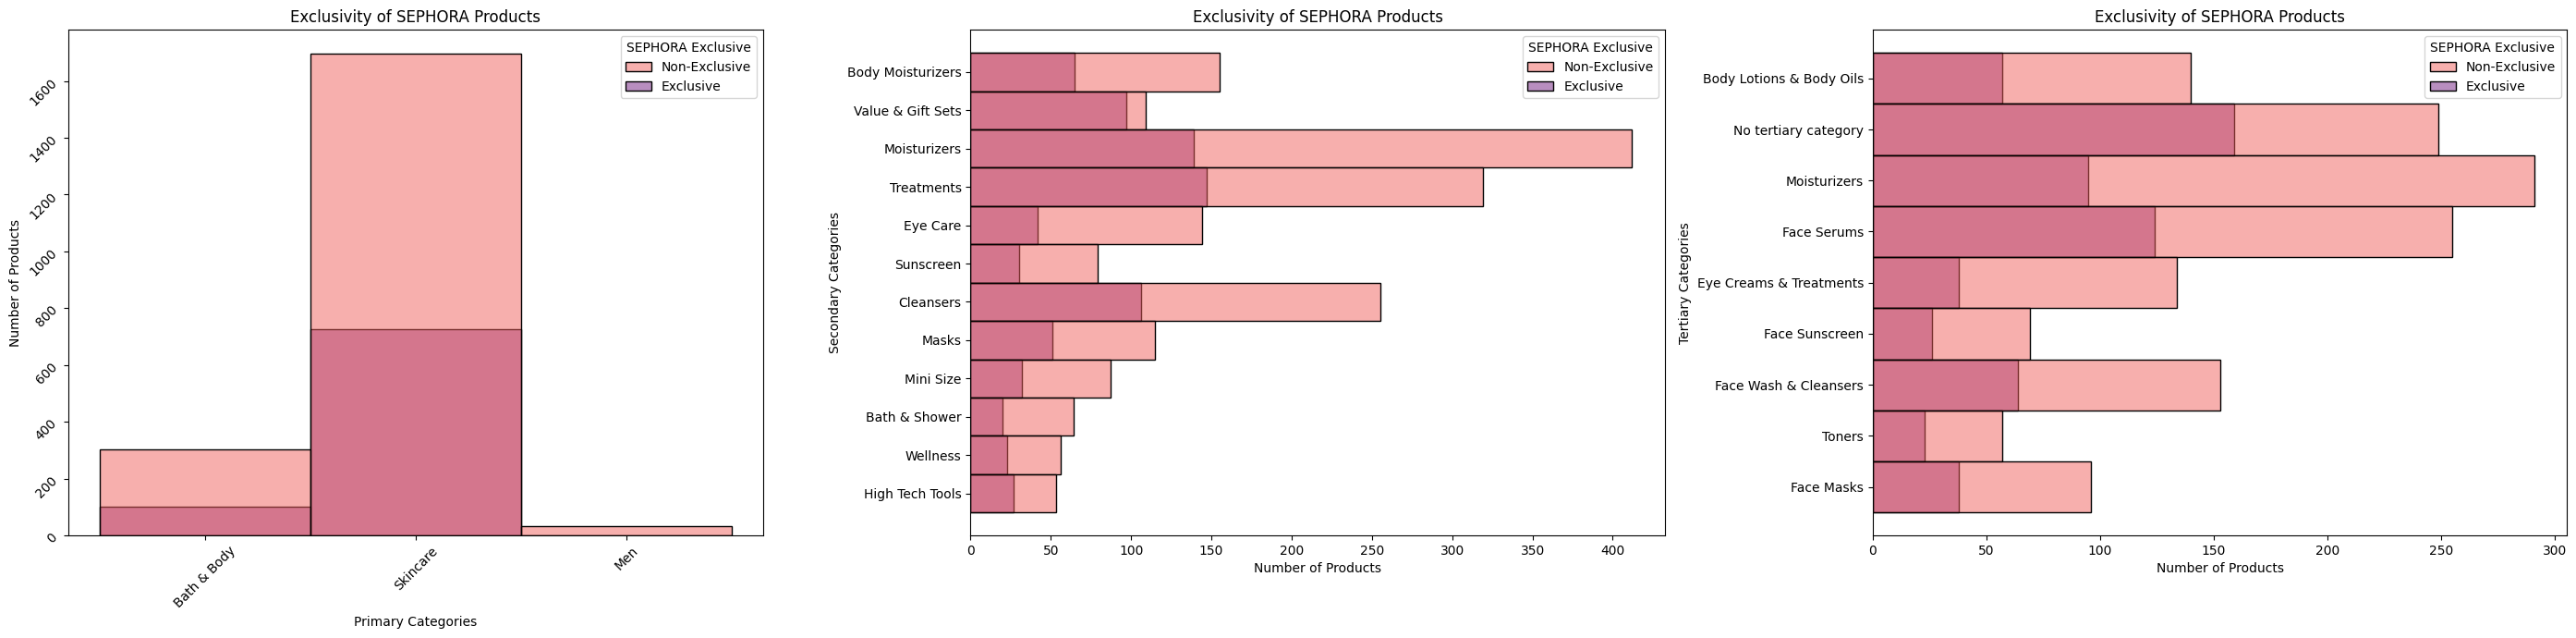

In [30]:
# <<<./  Products Category Distribution
fig, axes = plt.subplots(1, 3, figsize=(28, 7))

# <<<./ Primary Category
a = sns.histplot(seph_prod_df, x='primary_category', hue='sephora_exclusive', palette='magma_r', ax=axes[0])
a.get_legend().set_title('SEPHORA Exclusive')
for i, j in zip(a.get_legend().get_texts(), ['Non-Exclusive', 'Exclusive']):
    i.set_text(j)
axes[0].set_xlabel('Primary Categories')
axes[0].set_ylabel('Number of Products')
axes[0].tick_params(rotation=45)
axes[0].set_title('Exclusivity of SEPHORA Products')

# <<<./ Secondary Category
b_counts = seph_prod_df['secondary_category'].value_counts()
b_keep = b_counts[b_counts > 75].index
b_df = seph_prod_df[seph_prod_df['secondary_category'].isin(b_keep)]
b = sns.histplot(b_df, y='secondary_category', hue='sephora_exclusive', palette='magma_r', ax=axes[1])
b.get_legend().set_title('SEPHORA Exclusive')
for i, j in zip(b.get_legend().get_texts(), ['Non-Exclusive', 'Exclusive']):
    i.set_text(j)
axes[1].set_xlabel('Number of Products')
axes[1].set_ylabel('Secondary Categories')
axes[1].set_title('Exclusivity of SEPHORA Products')

# <<<./ Tertiary Category
c_counts = seph_prod_df['tertiary_category'].value_counts()
c_keep = c_counts[c_counts > 75].index
c_df = seph_prod_df[seph_prod_df['tertiary_category'].isin(c_keep)]
c = sns.histplot(c_df, y='tertiary_category', hue='sephora_exclusive', palette='magma_r', ax=axes[2])
c.get_legend().set_title('SEPHORA Exclusive')
for i, j in zip(c.get_legend().get_texts(), ['Non-Exclusive', 'Exclusive']):
    i.set_text(j)
axes[2].set_xlabel('Number of Products')
axes[2].set_ylabel('Tertiary Categories')
axes[2].set_title('Exclusivity of SEPHORA Products')

plt.tight_layout()

In [40]:
len(seph_prod_df[(seph_prod_df['primary_category'] == 'Skincare') & (seph_prod_df['sephora_exclusive'] == 1)])/len(seph_prod_df[(seph_prod_df['primary_category'] == 'Skincare')])

0.29958677685950413

In [47]:
len(seph_prod_df[(seph_prod_df['primary_category'] == 'Bath & Body') & (seph_prod_df['sephora_exclusive'] == 1)])

102

In [52]:
len(seph_prod_df[(seph_prod_df['tertiary_category'] == 'No tertiary category')])/len(seph_prod_df)

0.14280714035701786

In [43]:
len(seph_prod_df)

2857

ValueError: Could not interpret value `loves_count` for `x`. An entry with this name does not appear in `data`.

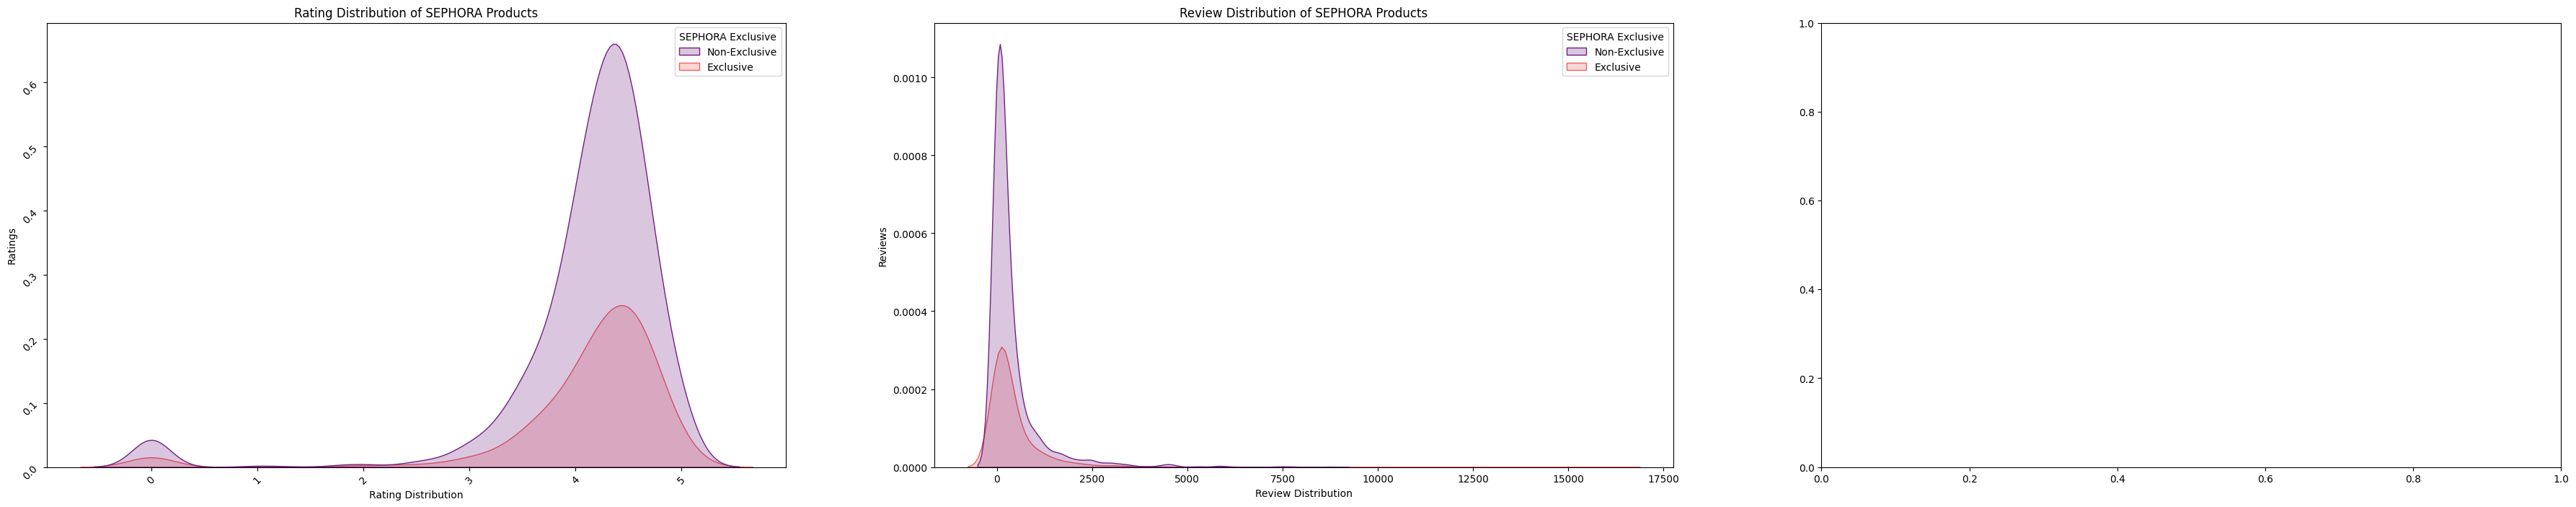

In [19]:
# Rating, Reviews, and Favorites Distribution
fig, axes = plt.subplots(1, 3, figsize=(45, 8))

# <<<./ Rating
d = sns.kdeplot(seph_prod_df, x='rating', hue='sephora_exclusive', palette='magma', ax=axes[0], fill=True)
d.get_legend().set_title('SEPHORA Exclusive')
for i, j in zip(d.get_legend().get_texts(), ['Non-Exclusive', 'Exclusive']):
    i.set_text(j)
axes[0].set_xlabel('Rating Distribution')
axes[0].set_ylabel('Ratings')
axes[0].tick_params(rotation=45)
axes[0].set_title('Rating Distribution of SEPHORA Products')

# <<<./ Reviews
e = sns.kdeplot(seph_prod_df, x='reviews', hue='sephora_exclusive', palette='magma', ax=axes[1], fill=True)
e.get_legend().set_title('SEPHORA Exclusive')
for i, j in zip(e.get_legend().get_texts(), ['Non-Exclusive', 'Exclusive']):
    i.set_text(j)
axes[1].set_xlabel('Review Distribution')
axes[1].set_ylabel('Reviews')
axes[1].set_title('Review Distribution of SEPHORA Products')

# <<<./ Loves Count
f = sns.kdeplot(seph_prod_df, x='loves_count', hue='sephora_exclusive', palette='magma', ax=axes[2], fill=True)
f.get_legend().set_title('SEPHORA Exclusive')
for i, j in zip(f.get_legend().get_texts(), ['Non-Exclusive', 'Exclusive']):
    i.set_text(j)
axes[2].set_xlabel('Loves Count Distribution')
axes[2].set_ylabel('Loves Count')
axes[2].set_title('Loves Count Distribution of SEPHORA Products')

plt.tight_layout()

## SEPHORA Product Reviews

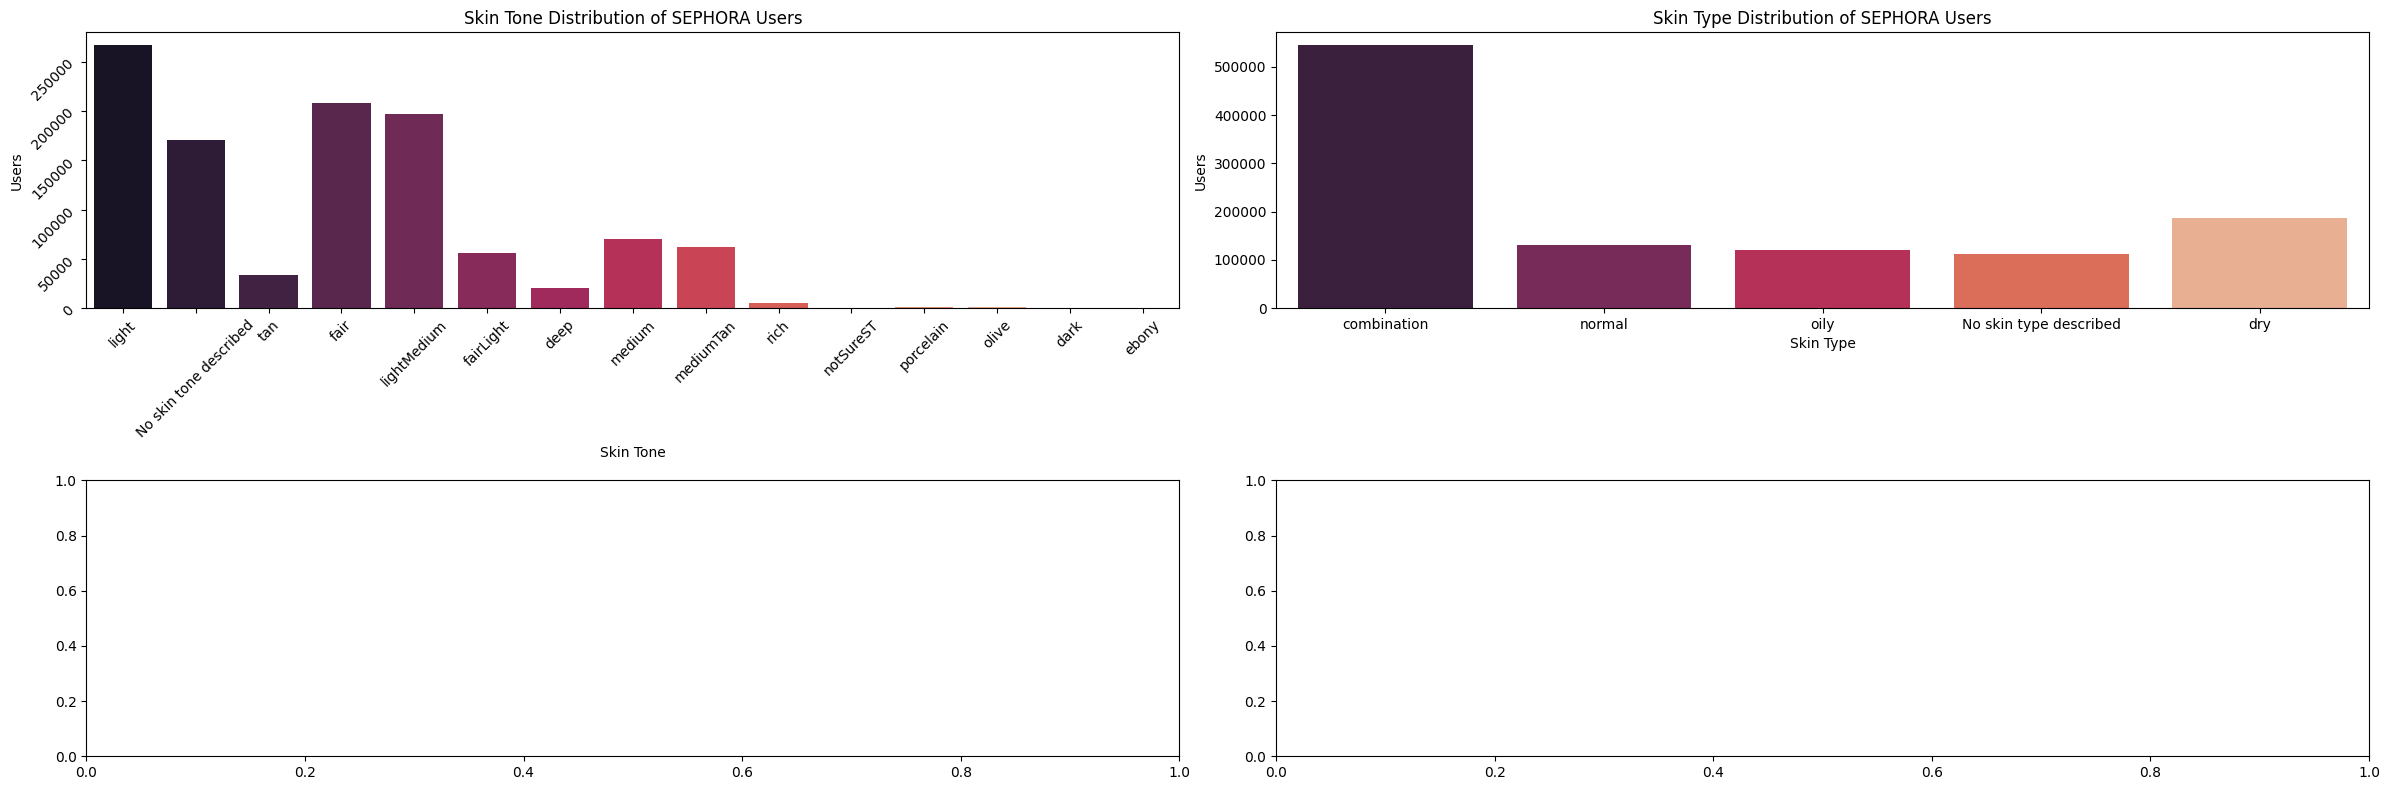

In [56]:
# <<<./ User Physical Feature
fig, axes = plt.subplots(2, 2, figsize=(24, 8))

# <<<./ Skin Tone
sns.countplot(seph_revw_df, x='skin_tone', hue='skin_tone', palette='rocket', ax=axes[0, 0])
axes[0, 0].set_xlabel('Skin Tone')
axes[0, 0].set_ylabel('Users')
axes[0, 0].tick_params(rotation=45)
axes[0, 0].set_title('Skin Tone Distribution of SEPHORA Users')

# <<<./ Skin Type
sns.countplot(seph_revw_df, x='skin_type', hue='skin_type', palette='rocket', ax=axes[0, 1])
axes[0, 1].set_xlabel('Skin Type')
axes[0, 1].set_ylabel('Users')
axes[0, 1].set_title('Skin Type Distribution of SEPHORA Users')
plt.tight_layout()

In [ ]:

# <<<./ Eye Color
sns.countplot(seph_revw_df, x='eye_color', hue='eye_color', palette='magma', ax=axes[1, 0])
axes[1, 0].set_xlabel('Eye Color')
axes[1, 0].set_ylabel('Users')
axes[1, 0].set_title('Eye Color Distribution of SEPHORA Users')

# <<<./ Hair Color
sns.countplot(seph_revw_df, x='hair_color', hue='hair_color', palette='magma', ax=axes[1, 1])
axes[1, 1].set_xlabel('Hair Color')
axes[1, 1].set_ylabel('Users')
axes[1, 1].set_title('Hair Color Distribution of SEPHORA Users')

In [ ]:
# <<<./ Most Frequent Words in Reviews
reviews = seph_revw_df.loc[seph_revw_df['review_title'] != 'No reviews written', 'review_title']
reviews = ' '.join(reviews.dropna().astype(str))
reviews_map = WordCloud(width=800, height=400, background_color='white', colormap='magma_r', stopwords=None).generate(reviews)

fig, axes = plt.subplots(1, 2, figsize=(28, 8))
axes[0].imshow(reviews_map, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Keywords in Review Titles')

# <<<./ Most Reviewed Products
products = seph_revw_df['product_name']
products = ' '.join(products.dropna().astype(str))
products_map = WordCloud(width=800, height=400, background_color='white', colormap='magma_r', stopwords=None).generate(products)

axes[1].imshow(products_map, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Most Reviewed Products')

plt.subplots_adjust(wspace=0.8)
plt.tight_layout()

## Ingredients Information

In [ ]:
# <<<./ Ingredients Distribution by Function and Warning, colored by Origin
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

origin_labels = ['Synthetic', 'Natural', 'Natural Derivative']

# <<<./ Function 1
g_counts = ingredients_df['function1'].value_counts()
g_keep = g_counts[g_counts > 10].index
g_df = ingredients_df[ingredients_df['function1'].isin(g_keep)]
g = sns.histplot(g_df, x='function1', hue='ingredient_origin', palette='magma', ax=axes[0, 0])
g.get_legend().set_title('Ingredient Origin')
for txt, label in zip(g.get_legend().get_texts(), origin_labels):
    txt.set_text(label)
axes[0, 0].set_xlabel('Function 1')
axes[0, 0].set_ylabel('Number of Ingredients')
axes[0, 0].tick_params(rotation=45)
axes[0, 0].set_title('Ingredients Function 1')

# <<<./ Function 2
h_counts = ingredients_df['function2'].value_counts()
h_keep = h_counts[h_counts > 3].index
h_df = ingredients_df[ingredients_df['function2'].isin(h_keep)]
h = sns.histplot(h_df, x='function2', hue='ingredient_origin', palette='magma', ax=axes[0, 1])
h.get_legend().set_title('Ingredient Origin')
for txt, label in zip(h.get_legend().get_texts(), origin_labels):
    txt.set_text(label)
axes[0, 1].set_xlabel('Function 2')
axes[0, 1].set_ylabel('Number of Ingredients')
axes[0, 1].tick_params(rotation=45)
axes[0, 1].set_title('Ingredients Function 2')

# <<<./ Warning 1
i_counts = ingredients_df['warning1'].value_counts()
i_keep = i_counts[i_counts > 0].index
i_df = ingredients_df[ingredients_df['warning1'].isin(i_keep)]
i = sns.histplot(i_df, x='warning1', hue='ingredient_origin', palette='magma', ax=axes[1, 0])
i.get_legend().set_title('Ingredient Origin')
for txt, label in zip(i.get_legend().get_texts(), origin_labels):
    txt.set_text(label)
axes[1, 0].set_xlabel('Warning 1')
axes[1, 0].set_ylabel('Number of Ingredients')
axes[1, 0].tick_params(rotation=45)
axes[1, 0].set_title('Ingredients Side-effects 1')

# <<<./ Warning 2
j_counts = ingredients_df['warning2'].value_counts()
j_keep = j_counts[j_counts > 0].index
j_df = ingredients_df[ingredients_df['warning2'].isin(j_keep)]
j = sns.histplot(j_df, x='warning2', hue='ingredient_origin', palette='magma', ax=axes[1, 1])
j.get_legend().set_title('Ingredient Origin')
for txt, label in zip(j.get_legend().get_texts(), origin_labels):
    txt.set_text(label)
axes[1, 1].set_xlabel('Warning 2')
axes[1, 1].set_ylabel('Number of Ingredients')
axes[1, 1].tick_params(rotation=45)
axes[1, 1].set_title('Ingredients Side-effects 2')

plt.tight_layout()

In [ ]:
seph_revw_df.columns

In [ ]:
seph_prod_df.columns

In [ ]:
seph_revw_df.info()

In [ ]:
seph_prod_df.info()

In [ ]:
ingredients_df.columns

In [ ]:
ingredients_df.info()

In [ ]:
seph_prod_df['ingredients'][2]


In [ ]:
ingredients_df['ingredient_name'][1:5]

In [ ]:
ingredients_df['function2'].value_counts()